In [1]:
import pandas as pd
import numpy as np

# For visualization 
import plotly.express as px
import plotly.graph_objects as go

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


In [2]:
df = pd.read_excel("Kittchen PNL Data.xlsx", header =1)

df.head()

,MONTH,CITY,STORE,STATUS,ZONE MAPPING,ORDER COUNT,CART SALES,DISCOUNT,NET REVENUE,IDEAL FOOD COST,GROSS MARGIN,KITCHEN EBITDA,VARIANCE,REVENUE COHORT,CM COHORT,EBITDA CATEGORY,EBITDA COHORT
0,Oct-2023,Ahmedabad,Ramos-Martin,Inactive,West,14270,6554333.68,1163493.98,5434068.17,1763679.62,3614747.39,2374914.55,29664.62,INR 20 to 30 lacs,0% to 10%,EBITDA +ve,More than 20%
1,Nov-2023,Ahmedabad,Ramos-Martin,Inactive,West,8528,2637625.82,636015.27,2146679.55,638415.30,1414249.00,151761.82,11769.85,INR 20 to 30 lacs,More than 30%,EBITDA +ve,More than 20%
2,Dec-2023,Ahmedabad,Ramos-Martin,Inactive,West,10798,4364193.67,1283840.18,3188606.71,1085080.58,2036999.44,736811.76,23376.83,INR 30 to 40 lacs,0% to 10%,EBITDA +ve,0% to 10%
3,Jan-2024,Ahmedabad,Ramos-Martin,Inactive,West,7804,3479969.32,854797.46,2734306.33,1180892.50,1451140.55,229924.26,26162.41,INR 20 to 30 lacs,0% to 10%,EBITDA +ve,More than 20%
4,Feb-2024,Ahmedabad,Ramos-Martin,Inactive,West,10060,4771378.71,1290900.38,3602124.88,1114846.94,2394567.16,1114151.65,19944.97,INR 20 to 30 lacs,More than 30%,EBITDA -ve,0% to 10%


In [3]:
df.shape

(2100, 17)

In [4]:
df.columns

Index(['MONTH', 'CITY', 'STORE', 'STATUS', 'ZONE MAPPING', 'ORDER COUNT',
       'CART SALES', 'DISCOUNT', 'NET REVENUE', 'IDEAL FOOD COST',
       'GROSS MARGIN', 'KITCHEN EBITDA', 'VARIANCE', 'REVENUE COHORT',
       'CM COHORT', 'EBITDA CATEGORY', 'EBITDA COHORT'],
      dtype='object')

In [5]:
df.shape

(2100, 17)

In [6]:
df.info

<bound method DataFrame.info of          MONTH       CITY                     STORE    STATUS ZONE MAPPING  \
0     Oct-2023  Ahmedabad              Ramos-Martin  Inactive         West   
1     Nov-2023  Ahmedabad              Ramos-Martin  Inactive         West   
2     Dec-2023  Ahmedabad              Ramos-Martin  Inactive         West   
3     Jan-2024  Ahmedabad              Ramos-Martin  Inactive         West   
4     Feb-2024  Ahmedabad              Ramos-Martin  Inactive         West   
...        ...        ...                       ...       ...          ...   
2095  Nov-2023     Mumbai  Jones, Knight and Rivers    Active         East   
2096  Dec-2023     Mumbai  Jones, Knight and Rivers    Active         East   
2097  Jan-2024     Mumbai  Jones, Knight and Rivers    Active         East   
2098  Feb-2024     Mumbai  Jones, Knight and Rivers    Active         East   
2099  Mar-2024     Mumbai  Jones, Knight and Rivers    Active         East   

      ORDER COUNT  CART SALES  

In [7]:
df.columns = df.columns.str.strip().str.replace(" ", "_")
df.columns

Index(['MONTH', 'CITY', 'STORE', 'STATUS', 'ZONE_MAPPING', 'ORDER_COUNT',
       'CART_SALES', 'DISCOUNT', 'NET_REVENUE', 'IDEAL_FOOD_COST',
       'GROSS_MARGIN', 'KITCHEN_EBITDA', 'VARIANCE', 'REVENUE_COHORT',
       'CM_COHORT', 'EBITDA_CATEGORY', 'EBITDA_COHORT'],
      dtype='object')

In [8]:
df.isnull().sum()

MONTH              0
CITY               0
STORE              0
STATUS             0
ZONE_MAPPING       0
ORDER_COUNT        0
CART_SALES         0
DISCOUNT           0
NET_REVENUE        0
IDEAL_FOOD_COST    0
GROSS_MARGIN       0
KITCHEN_EBITDA     0
VARIANCE           0
REVENUE_COHORT     0
CM_COHORT          0
EBITDA_CATEGORY    0
EBITDA_COHORT      0
dtype: int64

In [9]:
df.describe()

,ORDER_COUNT,CART_SALES,DISCOUNT,NET_REVENUE,IDEAL_FOOD_COST,GROSS_MARGIN,KITCHEN_EBITDA,VARIANCE
count,2100.000000,2.100000e+03,2.100000e+03,2.100000e+03,2.100000e+03,2.100000e+03,2.100000e+03,2100.000000
mean,11045.371905,4.400591e+06,9.839992e+05,3.505318e+06,1.362716e+06,2.043380e+06,6.847230e+05,20176.588981
std,2290.859134,1.119388e+06,3.136288e+05,8.948390e+05,4.151767e+05,5.724239e+05,5.810918e+05,5783.204330
min,7002.000000,2.177493e+06,3.521976e+05,1.726080e+06,5.567911e+05,8.628336e+05,-5.858504e+05,10018.480000
25%,9097.000000,3.520108e+06,7.442392e+05,2.817943e+06,1.059971e+06,1.612744e+06,2.520450e+05,15494.855000
50%,10987.000000,4.295395e+06,9.388061e+05,3.427512e+06,1.298579e+06,1.980660e+06,6.176177e+05,20195.190000
75%,12986.750000,5.184657e+06,1.176024e+06,4.127204e+06,1.618120e+06,2.423338e+06,1.076676e+06,25180.827500
max,14999.000000,7.471638e+06,2.147224e+06,6.167425e+06,2.797857e+06,4.172730e+06,2.834680e+06,29993.940000


In [10]:
df['MONTH'] = pd.to_datetime(df['MONTH'], format='%b-%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2100 entries, 0 to 2099
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   MONTH            2100 non-null   datetime64[ns]
 1   CITY             2100 non-null   object        
 2   STORE            2100 non-null   object        
 3   STATUS           2100 non-null   object        
 4   ZONE_MAPPING     2100 non-null   object        
 5   ORDER_COUNT      2100 non-null   int64         
 6   CART_SALES       2100 non-null   float64       
 7   DISCOUNT         2100 non-null   float64       
 8   NET_REVENUE      2100 non-null   float64       
 9   IDEAL_FOOD_COST  2100 non-null   float64       
 10  GROSS_MARGIN     2100 non-null   float64       
 11  KITCHEN_EBITDA   2100 non-null   float64       
 12  VARIANCE         2100 non-null   float64       
 13  REVENUE_COHORT   2100 non-null   object        
 14  CM_COHORT        2100 non-null   object 

## Core KPI Columns

In [11]:

df['GM_PERCENT'] = (df['GROSS_MARGIN'] / df['NET_REVENUE']) * 100

df['EBITDA_PERCENT'] = (df['KITCHEN_EBITDA'] / df['NET_REVENUE']) * 100

df['VARIANCE_PERCENT'] = (df['VARIANCE'] / df['IDEAL_FOOD_COST']) * 100

df[['GM_PERCENT', 'EBITDA_PERCENT', 'VARIANCE_PERCENT']].head()

,GM_PERCENT,EBITDA_PERCENT,VARIANCE_PERCENT
0,66.520096,43.704173,1.681973
1,65.880769,7.069608,1.843604
2,63.883684,23.107640,2.154387
3,53.071616,8.408870,2.215478
4,66.476517,30.930400,1.789032


## Feature Engineering

In this step, additional business KPI categories and variance buckets are created to support dashboard filtering and analytical segmentation.

### Revenue Bucket Creation

Revenue ranges are created to segment kitchens into operational performance cohorts. These cohorts help compare kitchen profitability and variance trends across different revenue scales.

In [12]:
def revenue_bucket(x):
    
    if x < 1500000:
        return "Below INR 15 lacs"
    
    elif x < 2500000:
        return "INR 15 to 25 lacs"
    
    elif x < 3500000:
        return "INR 25 to 35 lacs"
    
    elif x < 4500000:
        return "INR 35 to 45 lacs"
    
    else:
        return "Above INR 45 lacs"


df['REVENUE_BUCKET'] = df['NET_REVENUE'].apply(revenue_bucket)

display(df[['NET_REVENUE', 'REVENUE_BUCKET']].head(7))
display(df['REVENUE_BUCKET'].value_counts())

,NET_REVENUE,REVENUE_BUCKET
0,5434068.17,Above INR 45 lacs
1,2146679.55,INR 15 to 25 lacs
2,3188606.71,INR 25 to 35 lacs
3,2734306.33,INR 25 to 35 lacs
4,3602124.88,INR 35 to 45 lacs
5,3340397.87,INR 25 to 35 lacs
6,2837141.55,INR 25 to 35 lacs


REVENUE_BUCKET
INR 25 to 35 lacs    834
INR 35 to 45 lacs    689
Above INR 45 lacs    299
INR 15 to 25 lacs    278
Name: count, dtype: int64

### Variance Bucket Creation

Variance percentage buckets are created to classify kitchens based on food wastage efficiency. This segmentation will be used in the variance-level dashboard analysis.

In [13]:
def variance_bucket(x):
    
    if x < 2:
        return "Var < 2%"
    
    elif x < 3:
        return "Var 2% to 3%"
    
    elif x < 5:
        return "Var 3% to 5%"
    
    else:
        return "Var > 5%"


df['VARIANCE_BUCKET'] = df['VARIANCE_PERCENT'].apply(variance_bucket)

df['VARIANCE_BUCKET'] = df['VARIANCE_BUCKET'].replace({
    'Var < 2%': 'Var <2%',
    'Var 2% to 3%': 'Var 2-3%',
    'Var 3% to 5%': 'Var 3-5%',
    'Var >5%': 'Var >5%'
})

display(df['VARIANCE_BUCKET'].head(6))
print("\n") 
display(df['VARIANCE_BUCKET'].value_counts())

0     Var <2%
1     Var <2%
2    Var 2-3%
3    Var 2-3%
4     Var <2%
5     Var <2%
Name: VARIANCE_BUCKET, dtype: object

VARIANCE_BUCKET
Var <2%     1558
Var 2-3%     443
Var 3-5%      99
Name: count, dtype: int64

## EBITDA Status Bucket 
EBITDA status buckets are created to measure the proftability 

In [14]:
def ebitda_status(x):
    
    if x < 0:
        return "Loss Making"
    
    elif x < 10:
        return "Low Profit"
    
    elif x < 20:
        return "Moderate Profit"
    
    else:
        return "High Profit"


df['EBITDA_STATUS'] = df['EBITDA_PERCENT'].apply(ebitda_status)
display(df['EBITDA_STATUS'].head())
print('\n')
display(df['EBITDA_STATUS'].value_counts())

0    High Profit
1     Low Profit
2    High Profit
3     Low Profit
4    High Profit
Name: EBITDA_STATUS, dtype: object

EBITDA_STATUS
High Profit        921
Moderate Profit    600
Low Profit         338
Loss Making        241
Name: count, dtype: int64

In [15]:
df.to_csv("cleaned_kitchen_pnl.csv", index=False)

# Exploratory Data Analysis (EDA)

The objective of this section is to analyze operational and profitability trends across kitchens, cities, and revenue cohorts using visual analytics.

### Revenue Contribution by City

This analysis helps identify which cities contribute the highest revenue to the business and highlights location-wise operational concentration.

In [33]:
pd.options.display.float_format = '{:,.2f}'.format

In [34]:
city_revenue = df.groupby('CITY')['NET_REVENUE'].sum().reset_index()

city_revenue = city_revenue.sort_values(by='NET_REVENUE', ascending=False)

display(city_revenue.head())

,CITY,NET_REVENUE
0,Ahmedabad,"1,848,080,124.42"
2,Hyderabad,"1,512,075,939.95"
1,Bangalore,"1,430,733,267.99"
3,Mumbai,"1,303,669,038.86"
4,Pune,"1,266,609,809.08"


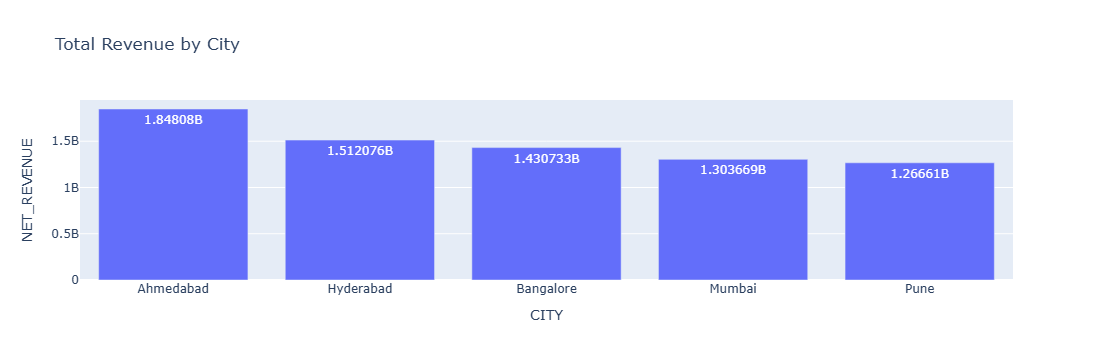

In [19]:
fig = px.bar(
    city_revenue,
    x='CITY',
    y='NET_REVENUE',
    title='Total Revenue by City',
    text_auto=True
)

fig.show()

### Top Performing Kitchens by EBITDA

This analysis identifies the most operationally profitable kitchen stores based on EBITDA contribution.

In [35]:
top_ebitda = df.groupby('STORE')['KITCHEN_EBITDA'].sum().reset_index()

top_ebitda = top_ebitda.sort_values(by='KITCHEN_EBITDA',ascending=False).head(10)

display(top_ebitda)

,STORE,KITCHEN_EBITDA
280,Smith Ltd,"12,096,497.47"
1,Adams LLC,"11,720,624.21"
269,Sanders Ltd,"11,702,593.79"
162,Jimenez LLC,"9,170,224.04"
267,Sanchez and Sons,"9,167,939.50"
99,Fuller LLC,"7,620,794.46"
187,"Mahoney, Dixon and Hobbs","7,537,180.56"
262,Rose and Sons,"7,499,551.77"
25,Barnes PLC,"7,254,693.48"
307,"Thompson, Hardy and Ramos","7,250,769.44"


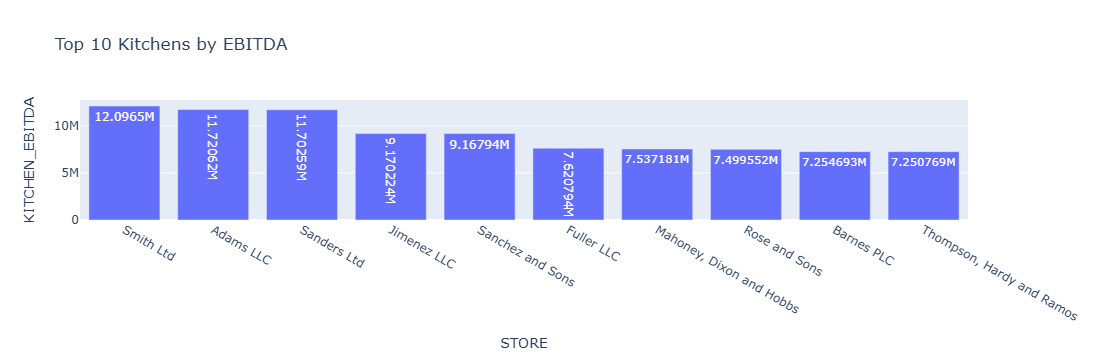

In [21]:
fig = px.bar(
    top_ebitda,
    x='STORE',
    y='KITCHEN_EBITDA',
    title='Top 10 Kitchens by EBITDA',
    text_auto=True
)

fig.show()

### Revenue vs EBITDA Analysis

This visualization helps analyze whether higher revenue kitchens also generate stronger operational profitability.

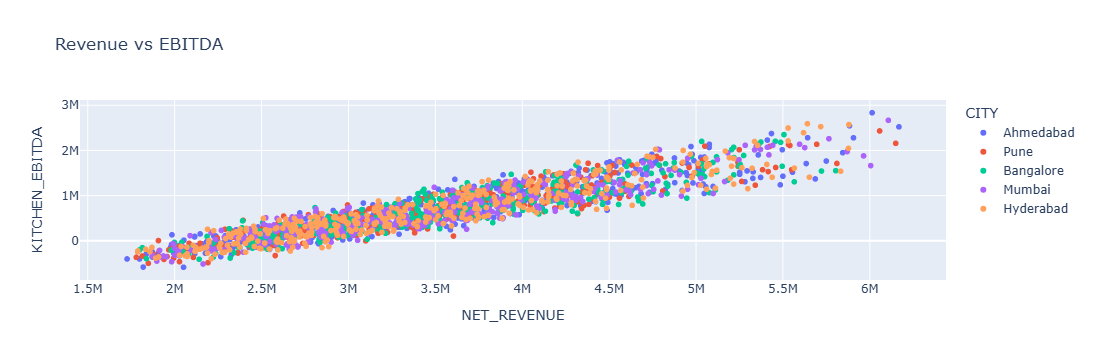

In [25]:
fig = px.scatter(
    df,
    x='NET_REVENUE',
    y='KITCHEN_EBITDA',
    color='CITY',
    hover_data=['STORE'],
    title='Revenue vs EBITDA'
)

fig.show()

### Variance Impact on Profitability

This analysis evaluates how food wastage variance affects kitchen-level EBITDA performance.

In [38]:
variance_analysis = df.groupby('VARIANCE_BUCKET')['EBITDA_PERCENT'].mean().reset_index()

display(variance_analysis)

,VARIANCE_BUCKET,EBITDA_PERCENT
0,Var 2-3%,10.30
1,Var 3-5%,4.11
2,Var <2%,19.38


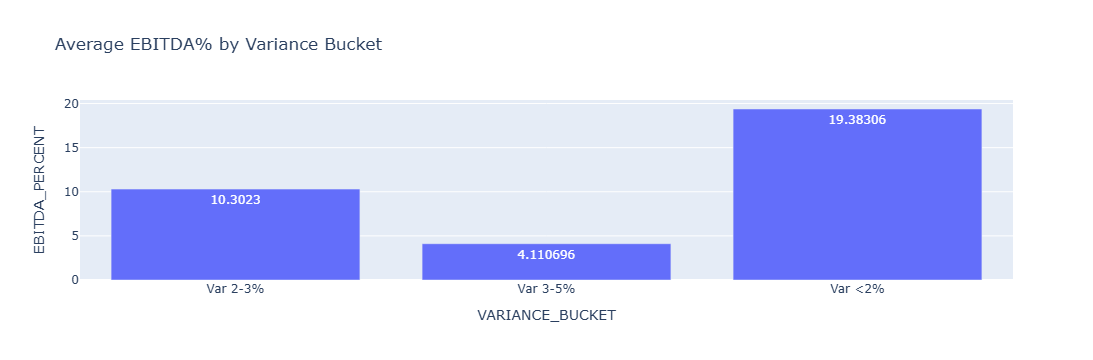

In [39]:
fig = px.bar(
    variance_analysis,
    x='VARIANCE_BUCKET',
    y='EBITDA_PERCENT',
    title='Average EBITDA% by Variance Bucket',
    text_auto=True
)

fig.show()

## Kitchen Level PNL Summary

This table provides month-wise operational and profitability metrics at the kitchen level. It will serve as the primary dataset for the Kitchen PNL dashboard.

In [45]:
kitchen_pnl_summary = df.groupby(
    ['MONTH', 'CITY', 'STORE']
).agg({
    'NET_REVENUE': 'sum',
    'GROSS_MARGIN': 'sum',
    'KITCHEN_EBITDA': 'sum',
    'ORDER_COUNT': 'sum',
    'VARIANCE': 'mean',
    'GM_PERCENT': 'mean',
    'EBITDA_PERCENT': 'mean'
}).reset_index()

display(kitchen_pnl_summary.head())

,MONTH,CITY,STORE,NET_REVENUE,GROSS_MARGIN,KITCHEN_EBITDA,ORDER_COUNT,VARIANCE,GM_PERCENT,EBITDA_PERCENT
0,2023-10-01,Ahmedabad,Adams LLC,"9,614,586.82","5,088,418.71","2,590,807.50",29536,"11,712.06",53.10,26.74
1,2023-10-01,Ahmedabad,Aguirre-Goodman,"3,014,886.72","1,521,874.71","215,856.18",10219,"19,757.02",50.48,7.16
2,2023-10-01,Ahmedabad,"Atkinson, Hale and Bowen","4,950,054.09","2,745,027.95","1,445,988.05",13671,"15,046.39",55.45,29.21
3,2023-10-01,Ahmedabad,"Baker, Baker and Horn","2,702,309.68","1,494,898.38","134,829.84",7804,"28,662.03",55.32,4.99
4,2023-10-01,Ahmedabad,Ball Ltd,"3,571,250.84","2,416,225.73","1,127,225.59",12119,"17,608.72",67.66,31.56


### Monthly Revenue Trend Analysis

This analysis tracks revenue movement across months to identify seasonality and operational growth trends.

In [46]:
monthly_revenue = df.groupby('MONTH')['NET_REVENUE'].sum().reset_index()

display(monthly_revenue)

,MONTH,NET_REVENUE
0,2023-10-01,"1,240,709,738.00"
1,2023-11-01,"1,215,370,538.63"
2,2023-12-01,"1,211,609,371.50"
3,2024-01-01,"1,247,390,925.20"
4,2024-02-01,"1,213,151,837.07"
5,2024-03-01,"1,232,935,769.90"


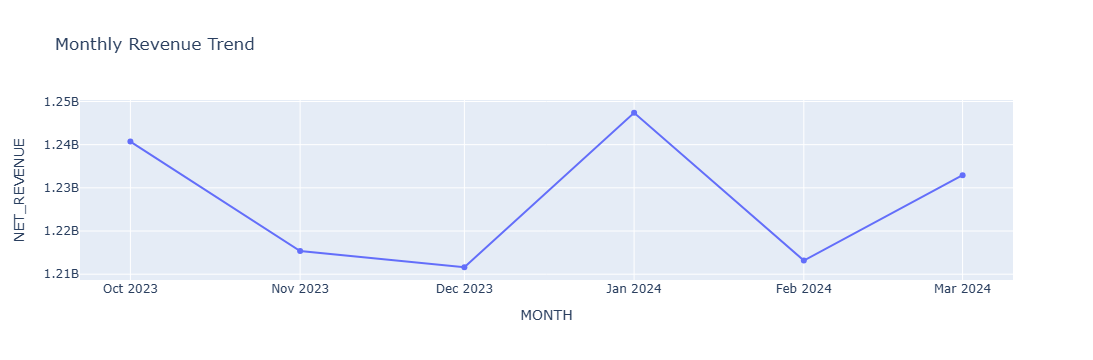

In [47]:
fig = px.line(
    monthly_revenue,
    x='MONTH',
    y='NET_REVENUE',
    title='Monthly Revenue Trend',
    markers=True
)

fig.show()

In [48]:
monthly_ebitda = df.groupby('MONTH')['KITCHEN_EBITDA'].sum().reset_index()

display(monthly_ebitda)

,MONTH,KITCHEN_EBITDA
0,2023-10-01,"250,176,947.56"
1,2023-11-01,"229,516,945.94"
2,2023-12-01,"231,913,262.13"
3,2024-01-01,"254,805,858.26"
4,2024-02-01,"234,066,259.11"
5,2024-03-01,"237,439,001.24"


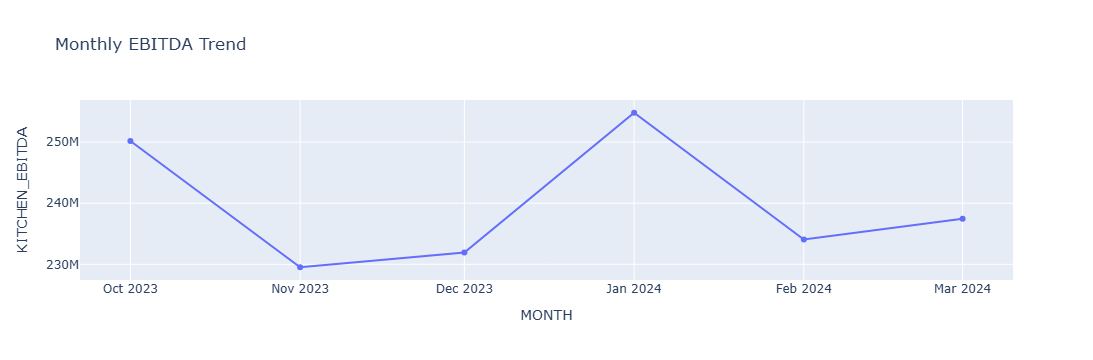

In [49]:
fig = px.line(
    monthly_ebitda,
    x='MONTH',
    y='KITCHEN_EBITDA',
    title='Monthly EBITDA Trend',
    markers=True
)

fig.show()

## Variance Dashboard Summary

This table summarizes average variance percentage across revenue cohorts and months for operational efficiency analysis.

In [50]:
variance_summary = df.pivot_table(
    values='VARIANCE_PERCENT',
    index='REVENUE_BUCKET',
    columns='MONTH',
    aggfunc='mean'
)

display(variance_summary)

MONTH,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01
REVENUE_BUCKET,,,,,,
Above INR 45 lacs,0.99,1.01,1.10,1.00,1.02,1.03
INR 15 to 25 lacs,2.35,2.39,2.69,2.54,2.54,2.15
INR 25 to 35 lacs,1.79,1.78,1.72,1.85,1.83,1.85
INR 35 to 45 lacs,1.28,1.39,1.41,1.32,1.41,1.27


### Store Count Analysis by Variance Bucket

This table shows the count of kitchen stores segmented by variance category and revenue cohort across different months.

In [51]:
store_count_summary = df.pivot_table(
    values='STORE',
    index=['VARIANCE_BUCKET', 'REVENUE_BUCKET'],
    columns='MONTH',
    aggfunc='count'
)

display(store_count_summary)

MONTH                              2023-10-01  2023-11-01  2023-12-01  \
VARIANCE_BUCKET REVENUE_BUCKET                                          
Var 2-3%        INR 15 to 25 lacs          12          27          19   
                INR 25 to 35 lacs          38          43          39   
                INR 35 to 45 lacs           4          13          15   
Var 3-5%        INR 15 to 25 lacs          11          11          13   
                INR 25 to 35 lacs           5           6           4   
Var <2%         Above INR 45 lacs          48          53          43   
                INR 15 to 25 lacs          20          18           9   
                INR 25 to 35 lacs          84          94         106   
                INR 35 to 45 lacs         128          85         102   

MONTH                              2024-01-01  2024-02-01  2024-03-01  
VARIANCE_BUCKET REVENUE_BUCKET                                         
Var 2-3%        INR 15 to 25 lacs          22          25          21  
                INR 25 to 35 lacs          50          40          44  
                INR 35 to 45 lacs           8          13          10  
Var 3-5%        INR 15 to 25 lacs          12          10           6  
                INR 25 to 35 lacs           4           9           8  
Var <2%         Above INR 45 lacs          58          44          53  
                INR 15 to 25 lacs          11          10          21  
                INR 25 to 35 lacs          85          91          84  
                INR 35 to 45 lacs         100         108         103

In [52]:
kitchen_pnl_summary.to_csv("kitchen_pnl_summary.csv", index=False)

monthly_revenue.to_csv("monthly_revenue.csv", index=False)

monthly_ebitda.to_csv("monthly_ebitda.csv", index=False)

variance_summary.to_csv("variance_summary.csv")

store_count_summary.to_csv("store_count_summary.csv")

## Key Business Insights

- Kitchens with variance below 2% consistently achieve stronger EBITDA margins.
- Higher revenue kitchens demonstrate better operational efficiency.
- Variance percentage appears inversely related to profitability.
- Significant EBITDA differences exist across revenue cohorts and cities.

## Conclusion

The analysis indicates that operational efficiency and food variance management significantly impact kitchen profitability. Kitchens maintaining lower wastage percentages consistently achieve stronger EBITDA performance.

The dashboards enable business stakeholders to dynamically analyze kitchen-level performance and identify operational improvement opportunities.